⏳  Cargando datos desde Google Sheets...
✅  119 filas cargadas.

🧹  Limpiando datos...
   Filas eliminadas por datos nulos: 39
✅  Datos limpios: 80 filas.

         📊  KPIs FIT_LAND
  💰  Ingreso total    : $   17,106.00
  📦  Costo total      : $    7,886.00
  📈  Ganancia total   : $    9,220.00
  🎯  Margen promedio  :         54.5%
  🛍️   Unidades vendidas:           80
  🧾  Ticket promedio  : $      213.82

🖼️   Dashboard guardado como 'fitland_dashboard.png'


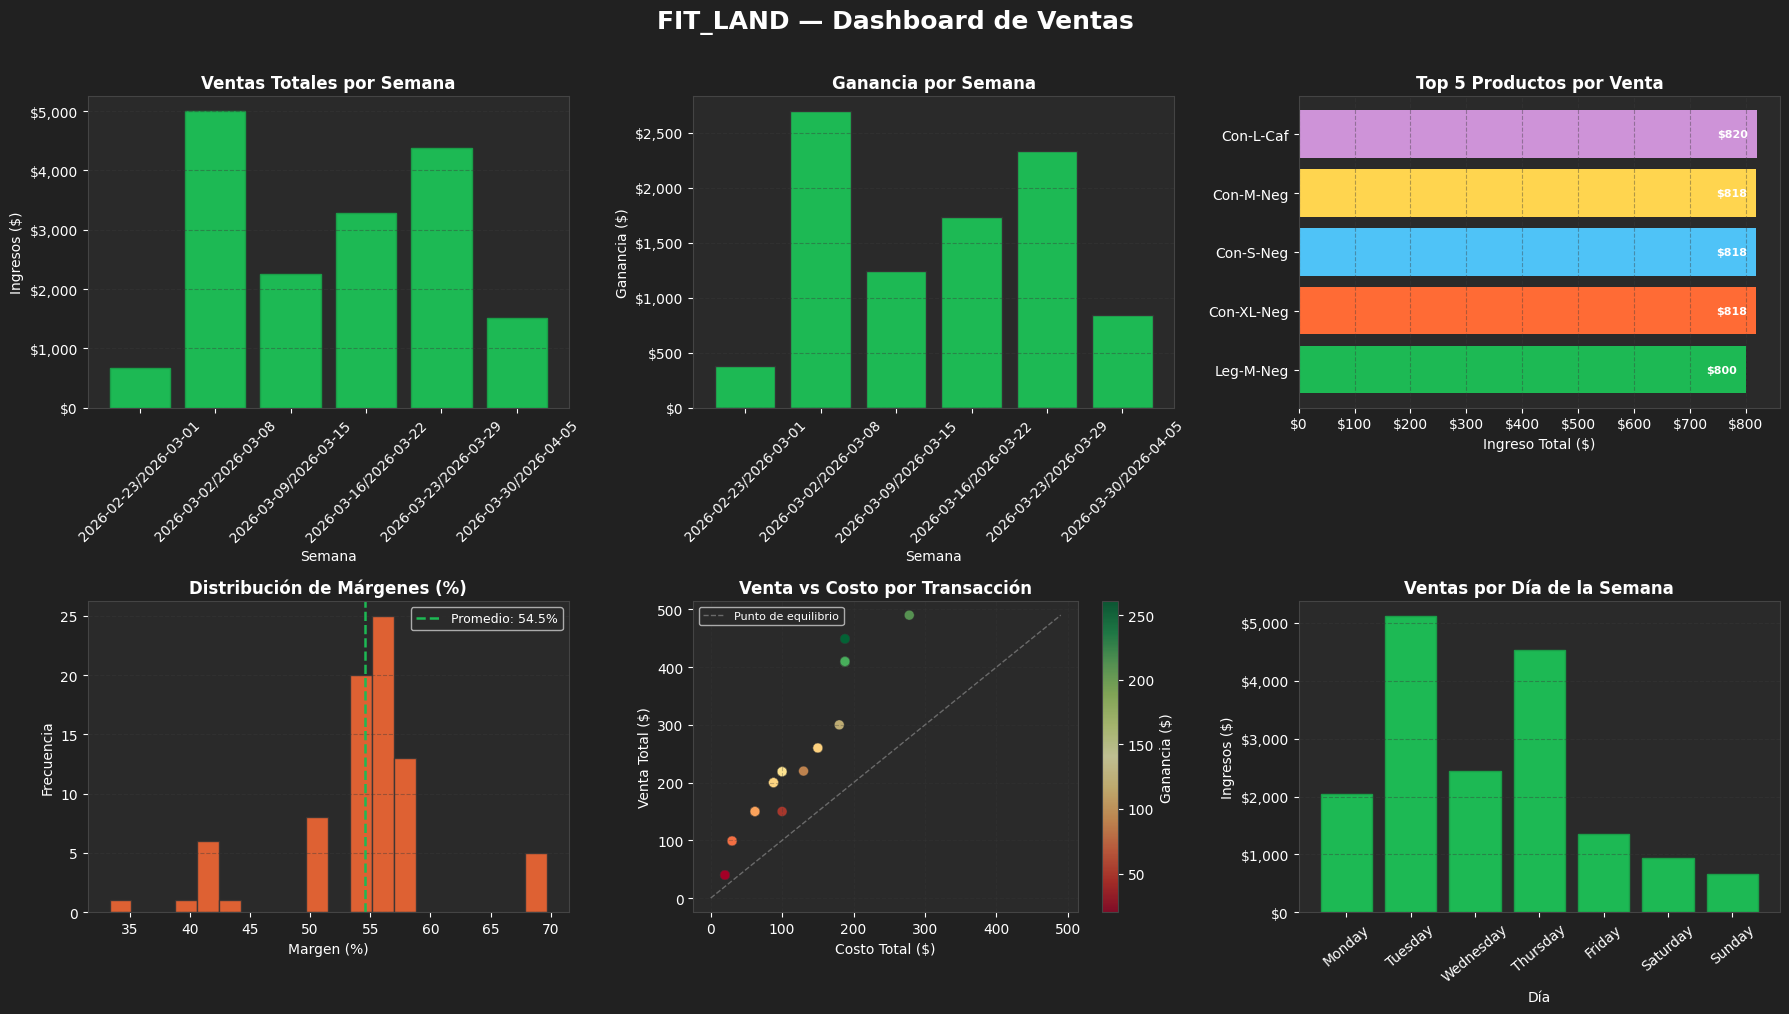

📁  Datos limpios exportados como 'fitland_clean.csv'

✅  Análisis completo.


In [1]:
# ============================================================
#   FIT_LAND — Análisis de Ventas
#   Autor: FIT_LAND Data Pipeline
#   Descripción: Limpieza, análisis y visualización de ventas
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import sys

warnings.filterwarnings("ignore")

# ── CONFIG ───────────────────────────────────────────────────
SHEET_URL = (
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vT5hA6wziOv1my1P6qy43sopGbF3VUi4D--GJCAOEQCeecfr5Y3LnDwNUJHpy3NF7qc0MHVYkFQLSyQ/pub?output=csv"
)

COLOR_PRIMARY   = "#1DB954"   # verde FIT_LAND
COLOR_SECONDARY = "#212121"   # fondo oscuro
COLOR_ACCENT    = "#FF6B35"   # naranja acento
PALETTE         = [COLOR_PRIMARY, COLOR_ACCENT, "#4FC3F7", "#FFD54F", "#CE93D8"]

plt.rcParams.update({
    "figure.facecolor":  COLOR_SECONDARY,
    "axes.facecolor":    "#2A2A2A",
    "axes.edgecolor":    "#444",
    "axes.labelcolor":   "white",
    "xtick.color":       "white",
    "ytick.color":       "white",
    "text.color":        "white",
    "grid.color":        "#3A3A3A",
    "font.family":       "DejaVu Sans",
})


# ── 1. CARGA DE DATOS ────────────────────────────────────────
def cargar_datos(url: str) -> pd.DataFrame:
    print("⏳  Cargando datos desde Google Sheets...")
    try:
        df = pd.read_csv(url)
        print(f"✅  {len(df)} filas cargadas.\n")
        return df
    except Exception as e:
        print(f"❌  Error al cargar datos: {e}")
        sys.exit(1)


# ── 2. LIMPIEZA ──────────────────────────────────────────────
def limpiar_datos(df: pd.DataFrame) -> pd.DataFrame:
    print("🧹  Limpiando datos...")

    # Normalizar nombres de columnas
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace(r"[^a-z0-9_]", "", regex=True)
    )

    # Eliminar columnas sin nombre
    df = df.loc[:, ~df.columns.str.contains("unnamed", na=False)]

    # Fecha
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    # Limpiar y convertir columnas numéricas
    cols_dinero = ["precio_de_venta", "costo_unitario"]
    for col in cols_dinero:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace("$", "", regex=False)
                .str.replace(",", "", regex=False)
                .str.strip()
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["cantidad"] = pd.to_numeric(df["cantidad"], errors="coerce")

    # Eliminar filas sin datos clave
    antes = len(df)
    df = df.dropna(subset=["precio_de_venta", "cantidad", "costo_unitario", "fecha"])
    despues = len(df)
    print(f"   Filas eliminadas por datos nulos: {antes - despues}")

    # Columnas calculadas
    df["total_venta"]  = df["precio_de_venta"] * df["cantidad"]
    df["total_costo"]  = df["costo_unitario"]  * df["cantidad"]
    df["ganancia"]     = df["total_venta"] - df["total_costo"]
    df["margen_%"]     = (df["ganancia"] / df["total_venta"] * 100).round(2)

    # Columnas de tiempo
    df["mes"]       = df["fecha"].dt.to_period("M").astype(str)
    df["semana"]    = df["fecha"].dt.to_period("W").astype(str)
    df["dia_semana"]= df["fecha"].dt.day_name()

    print(f"✅  Datos limpios: {len(df)} filas.\n")
    return df


# ── 3. KPIs ──────────────────────────────────────────────────
def mostrar_kpis(df: pd.DataFrame):
    ingreso_total  = df["total_venta"].sum()
    costo_total    = df["total_costo"].sum()
    ganancia_total = df["ganancia"].sum()
    margen_prom    = df["margen_%"].mean()
    unidades       = df["cantidad"].sum()
    ticket_prom    = ingreso_total / len(df)

    print("=" * 45)
    print("         📊  KPIs FIT_LAND")
    print("=" * 45)
    print(f"  💰  Ingreso total    : ${ingreso_total:>12,.2f}")
    print(f"  📦  Costo total      : ${costo_total:>12,.2f}")
    print(f"  📈  Ganancia total   : ${ganancia_total:>12,.2f}")
    print(f"  🎯  Margen promedio  : {margen_prom:>12.1f}%")
    print(f"  🛍️   Unidades vendidas: {int(unidades):>12,}")
    print(f"  🧾  Ticket promedio  : ${ticket_prom:>12,.2f}")
    print("=" * 45 + "\n")


# ── 4. VISUALIZACIONES ───────────────────────────────────────
def graficar(df: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("FIT_LAND — Dashboard de Ventas", fontsize=18, fontweight="bold",
                 color="white", y=1.01)
    fig.patch.set_facecolor(COLOR_SECONDARY)

    # ── Gráfica 1: Ventas por semana ─────────────────────────────
    ax1 = axes[0, 0]
    ventas_semana = df.groupby("semana")["total_venta"].sum().reset_index()
    ax1.bar(ventas_semana["semana"], ventas_semana["total_venta"],
            color=COLOR_PRIMARY, edgecolor="#1a9e48")
    ax1.set_title("Ventas Totales por Semana", fontweight="bold")
    ax1.set_xlabel("Semana")
    ax1.set_ylabel("Ingresos ($)")
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax1.tick_params(axis="x", rotation=45)
    ax1.grid(axis="y", linestyle="--", alpha=0.4)

    # ── Gráfica 2: Ganancia por semana ───────────────────────────
    ax2 = axes[0, 1]
    gan_semana = df.groupby("semana")["ganancia"].sum().reset_index()
    colores_barras = [COLOR_PRIMARY if v >= 0 else COLOR_ACCENT
                      for v in gan_semana["ganancia"]]
    ax2.bar(gan_semana["semana"], gan_semana["ganancia"],
            color=colores_barras, edgecolor="#333")
    ax2.set_title("Ganancia por Semana", fontweight="bold")
    ax2.set_xlabel("Semana")
    ax2.set_ylabel("Ganancia ($)")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax2.tick_params(axis="x", rotation=45)
    ax2.grid(axis="y", linestyle="--", alpha=0.4)

    # ── Gráfica 3: Top 5 productos ────────────────────────────
    ax3 = axes[0, 2]
    col_producto = "id" if "nombre" not in df.columns else "nombre"
    top5 = (df.groupby(col_producto)["total_venta"]
              .sum()
              .sort_values(ascending=True)
              .tail(5))
    bars = ax3.barh(top5.index.astype(str), top5.values,
                    color=PALETTE[:len(top5)])
    ax3.set_title("Top 5 Productos por Venta", fontweight="bold")
    ax3.set_xlabel("Ingreso Total ($)")
    ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax3.grid(axis="x", linestyle="--", alpha=0.4)
    for bar, val in zip(bars, top5.values):
        ax3.text(val * 0.98, bar.get_y() + bar.get_height() / 2,
                 f"${val:,.0f}", va="center", ha="right",
                 fontsize=8, color="white", fontweight="bold")

    # ── Gráfica 4: Distribución de márgenes ──────────────────
    ax4 = axes[1, 0]
    ax4.hist(df["margen_%"].dropna(), bins=20,
             color=COLOR_ACCENT, edgecolor="#333", alpha=0.85)
    ax4.axvline(df["margen_%"].mean(), color=COLOR_PRIMARY,
                linestyle="--", linewidth=1.8, label=f"Promedio: {df['margen_%'].mean():.1f}%")
    ax4.set_title("Distribución de Márgenes (%)", fontweight="bold")
    ax4.set_xlabel("Margen (%)")
    ax4.set_ylabel("Frecuencia")
    ax4.legend(fontsize=9)
    ax4.grid(axis="y", linestyle="--", alpha=0.4)

    # ── Gráfica 5: Venta vs Costo (scatter) ───────────────────
    ax5 = axes[1, 1]
    scatter = ax5.scatter(df["total_costo"], df["total_venta"],
                          c=df["ganancia"], cmap="RdYlGn",
                          alpha=0.7, edgecolors="#333", linewidths=0.4, s=50)
    plt.colorbar(scatter, ax=ax5, label="Ganancia ($)")
    ax5.plot([0, df["total_venta"].max()],
             [0, df["total_venta"].max()],
             "--", color="white", alpha=0.3, linewidth=1, label="Punto de equilibrio")
    ax5.set_title("Venta vs Costo por Transacción", fontweight="bold")
    ax5.set_xlabel("Costo Total ($)")
    ax5.set_ylabel("Venta Total ($)")
    ax5.legend(fontsize=8)
    ax5.grid(linestyle="--", alpha=0.3)

    # ── Gráfica 6: Ventas por día de la semana ────────────────
    ax6 = axes[1, 2]
    orden_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    ventas_dia = (df.groupby("dia_semana")["total_venta"]
                    .sum()
                    .reindex(orden_dias, fill_value=0))
    ax6.bar(ventas_dia.index, ventas_dia.values,
            color=COLOR_PRIMARY, edgecolor="#1a9e48")
    ax6.set_title("Ventas por Día de la Semana", fontweight="bold")
    ax6.set_xlabel("Día")
    ax6.set_ylabel("Ingresos ($)")
    ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax6.tick_params(axis="x", rotation=40)
    ax6.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig("fitland_dashboard.png", dpi=150,
                bbox_inches="tight", facecolor=COLOR_SECONDARY)
    print("🖼️   Dashboard guardado como 'fitland_dashboard.png'")
    plt.show()


# ── 5. EXPORTAR ──────────────────────────────────────────────
def exportar(df: pd.DataFrame):
    df.to_csv("fitland_clean.csv", index=False)
    print("📁  Datos limpios exportados como 'fitland_clean.csv'")


# ── MAIN ─────────────────────────────────────────────────────
if __name__ == "__main__":
    df = cargar_datos(SHEET_URL)
    df = limpiar_datos(df)
    mostrar_kpis(df)
    graficar(df)
    exportar(df)
    print("\n✅  Análisis completo.")